# Rough Bergomi

This is a basic simulator and inference setup for the Rough Bergomi price path model, implemented using the rbergomi simulator from ryanmccrickerd on github and BayesFlow inference workflow.


In [1]:
import os

if "KERAS_BACKEND" not in os.environ:
    os.environ["KERAS_BACKEND"] = "jax"

import numpy as np
import bayesflow as bf
import matplotlib.pyplot as plt
from simulators.rbergomi import rBergomi

INFO:2026-05-05 17:13:05,192:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:bayesflow:Using backend 'jax'
/Users/kiran.j/PycharmProjects/BayesTool/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def draw_rb_priors() :
    rho = np.random.beta(3, 3) * 0.8 + 0.1
    eta = np.random.beta(5, 5) + 2
    xi = 0.235**2
    return dict(rho=float(rho), eta=float(eta), xi=float(xi))

In [3]:
def sample_bergomi(rho, eta, xi, n = 252, N = 1, T = 1.0, a = -0.43, seed = 1234) :
    rB = rBergomi(n = n, N = N, T = T, a = a)

    np.random.seed(seed)

    dW1 = rB.dW1()
    dW2 = rB.dW2()

    Y = rB.Y(dW1)

    dB = rB.dB(dW1, dW2, rho = rho)

    V = rB.V(Y, xi = xi, eta = eta)

    S = rB.S(V, dB, S0 = 100)[0]

    log_returns = np.log(S[1:] / S[:-1])

    return dict(log_returns=log_returns)

In [4]:
simulator = bf.make_simulator([draw_rb_priors, sample_bergomi])

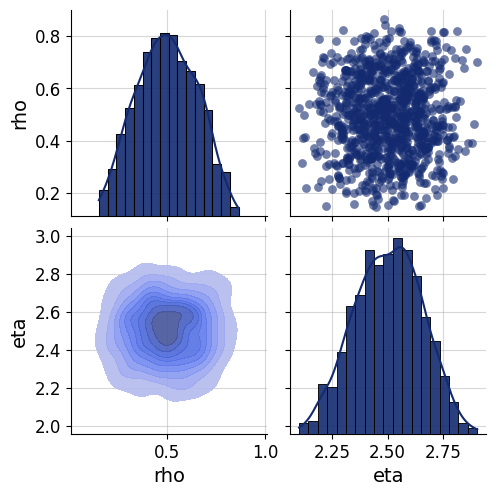

In [5]:
prior_samples = simulator.simulators[0].sample(1000)

grid = bf.diagnostics.plots.pairs_samples(
    prior_samples, variable_keys=["rho", "eta"]
)

In [5]:
adapter = (
    bf.adapters.Adapter()
    .convert_dtype("float64", "float32")
    .as_time_series("log_returns")
    .standardize(include="log_returns", mean=0, std=0.004)
    .standardize(include="rho", mean=-0.307, std=0.1435)
    .concatenate(["rho", "eta"], into="inference_variables")
    .rename("log_returns", "summary_variables")
)

In [6]:
summary_net = bf.networks.TimeSeriesNetwork(dropout=0.1)

inference_net = bf.networks.DiffusionModel(dropout=0.1)

workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    summary_network=summary_net,
    inference_network=inference_net,
    checkpoint_path="motion_workflow/"
)

In [7]:
train = workflow.simulate(10000)
validation = workflow.simulate(300)

In [8]:
history = workflow.fit_offline(data=train,
                               epochs=100,
                               batch_size=32,
                               validation_data=validation)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - loss: 2.8633 - val_loss: 1.6069
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - loss: 1.8423 - val_loss: 0.8271
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - loss: 0.8951 - val_loss: 1.0062
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - loss: 0.6554 - val_loss: 0.6967
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - loss: 0.6672 - val_loss: 0.6169
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - loss: 0.5981 - val_loss: 0.4231
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - loss: 0.5381 - val_loss: 0.3645
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - loss: 0.5320 - val_loss: 0.8051
Epoch 9/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - loss: 0.3956 - val_loss: 0.2578
Epoch 10/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - loss: 0.5528 - val_loss: 0.7237
Epoch 11/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - loss: 0.4683 - val_loss: 0.3342
Epoch 12/100
313/31

INFO:bayesflow:Training completed in 22.66 minutes.


[]

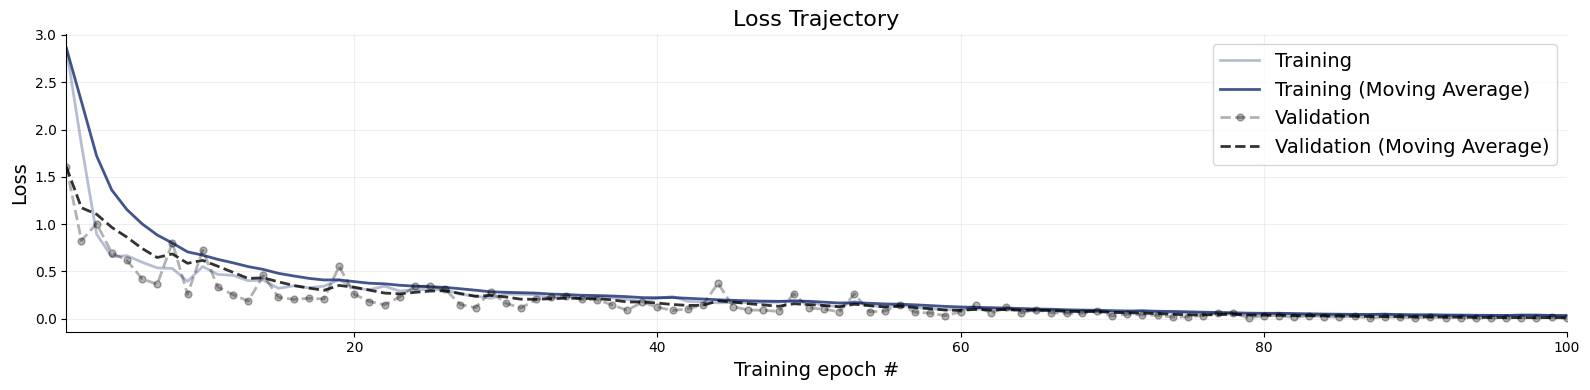

In [9]:
f = bf.diagnostics.plots.loss(history)
plt.plot()

Running simulations
Sampling


Sampling: 100%|██████████| 1/1 [05:51<00:00, 351.93s/batch]
INFO:bayesflow:Sampling completed in 5.87 minutes.


Making plots


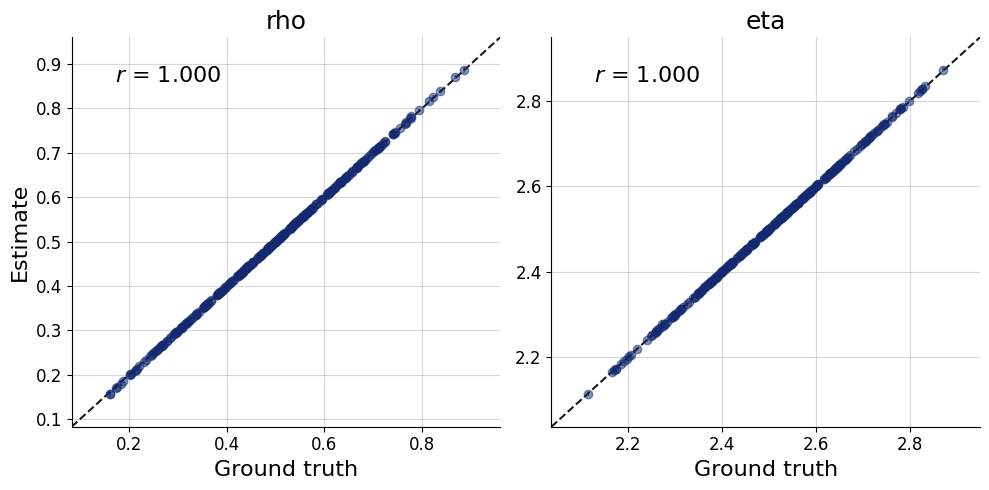

In [10]:
num_datasets = 300
num_samples = 1000

# Simulate 300 scenarios
print("Running simulations")
test_sims = workflow.simulate(num_datasets)

# Obtain num_samples posterior samples per scenario
print("Sampling")
samples = workflow.sample(conditions=test_sims, num_samples=num_samples)

print("Making plots")
f = bf.diagnostics.plots.recovery(samples, test_sims)

plt.savefig("bergomi_recoveries.png")

[]

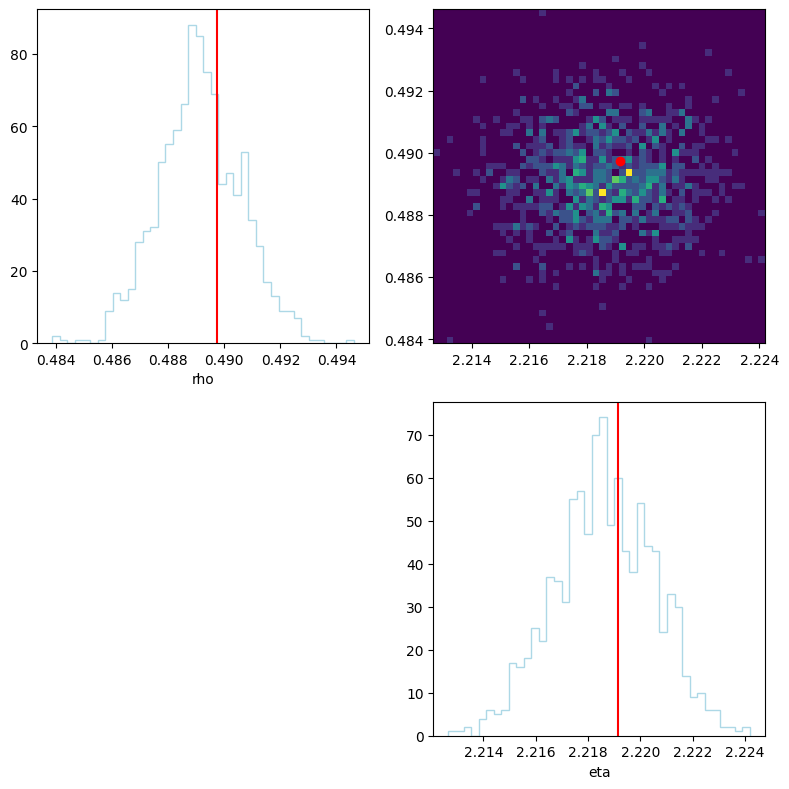

In [11]:
labels = ["rho", "eta"]

truths = np.asarray([test_sims[labels[x]][0].item() for x in range(len(labels))])

out_samples = np.asarray([samples[labels[x]][0].flatten() for x in range(len(labels))]).T

d = out_samples.shape[1]
fig, axes = plt.subplots(d, d, figsize=(8, 8))

for i in range(d):
    for j in range(d):
        ax = axes[i, j]
        if i == j:
            ax.set_facecolor("white")  # set background blue
            ax.hist(out_samples[:, i], bins=40, histtype="step", color="lightblue")
            ax.axvline(truths[i], color="red")
            ax.set_xlabel(labels[i])
        elif i < j:
            ax.set_facecolor("midnightblue")  # set background blue
            h = ax.hist2d(out_samples[:, j], out_samples[:, i],
                          bins=50, cmap="viridis")
            ax.plot(truths[j], truths[i], "o", color="red")
        else:
            ax.axis("off")

plt.tight_layout()

plt.plot()